### A MNIST-like fashion product database

In this, we classify the images into respective classes given in the dataset. We use a Neural Net and a Deep Neural Net in Keras to solve this and check the accuracy scores.

### Load tensorflow

In [1]:
import tensorflow as tf
tf.set_random_seed(42)

In [2]:
tf.__version__

'1.13.1'

### Collect Data

In [3]:
import keras

Using TensorFlow backend.


In [4]:
(trainX, trainY), (testX, testY) = keras.datasets.fashion_mnist.load_data()

In [5]:
trainX.shape

(60000, 28, 28)

In [6]:
print(testY[0:5])

[9 2 1 1 6]


### Convert both training and testing labels into one-hot vectors.

**Hint:** check **tf.keras.utils.to_categorical()**

In [7]:
from keras.utils import to_categorical
Y_train=to_categorical(trainY,num_classes=10)
Y_test=to_categorical(testY,num_classes=10)

In [8]:
print(Y_train.shape)
print('First 5 examples now are: ', Y_train[0:5])

(60000, 10)
First 5 examples now are:  [[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [9]:
print(Y_test.shape)
print('First 5 examples now are: ', Y_test[0:5])

(10000, 10)
First 5 examples now are:  [[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]]


### Visualize the data

Plot first 10 images in the triaining set and their labels.

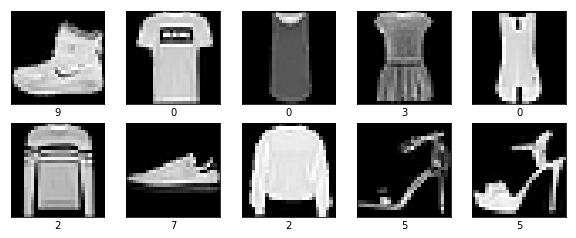

In [10]:
#Plot first 10 images in the triaining set and their labels.
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(10,10))
for i in range(10):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(trainX[i],cmap='gray')
    plt.xlabel(trainY[i])
plt.show()

### Build a neural Network with a cross entropy loss function and sgd optimizer in Keras. The output layer with 10 neurons as we have 10 classes.

In [11]:
from keras.models import Sequential
from keras.layers.core import Dense,Dropout,Activation,Flatten
from keras.layers.convolutional import Conv2D,MaxPooling2D
from keras.utils import np_utils
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(10, activation=tf.nn.softmax)
])

Instructions for updating:
Colocations handled automatically by placer.


In [12]:
model.compile(optimizer='sgd',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

### Execute the model using model.fit()

In [13]:
# convert from integers to floats
train_norm = trainX.astype('float32')
test_norm = testX.astype('float32')
# normalize to range 0-1
train_norm = train_norm / 255.0
test_norm = test_norm / 255.0

In [14]:
model.fit(train_norm, Y_train, epochs=10)

Instructions for updating:
Use tf.cast instead.
Epoch 1/10
60000/60000 [==============================] - 2s 33us/step - loss: 0.8255 - acc: 0.7393
Epoch 2/10
60000/60000 [==============================] - 2s 32us/step - loss: 0.5921 - acc: 0.8074
Epoch 3/10
60000/60000 [==============================] - 2s 28us/step - loss: 0.5432 - acc: 0.8210
Epoch 4/10
60000/60000 [==============================] - 2s 29us/step - loss: 0.5159 - acc: 0.8284
Epoch 5/10
60000/60000 [==============================] - 2s 29us/step - loss: 0.4986 - acc: 0.8331
Epoch 6/10
60000/60000 [==============================] - 2s 29us/step - loss: 0.4859 - acc: 0.8365
Epoch 7/10
60000/60000 [==============================] - 2s 29us/step - loss: 0.4761 - acc: 0.8397
Epoch 8/10
60000/60000 [==============================] - 2s 30us/step - loss: 0.4679 - acc: 0.8425
Epoch 9/10
60000/60000 [==============================] - 2s 32us/step - loss: 0.4617 - acc: 0.8442
Epoch 10/10
60000/60000 [===========================

In [15]:
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_1 (Flatten)          (None, 784)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 10)                7850      
Total params: 7,850
Trainable params: 7,850
Non-trainable params: 0
_________________________________________________________________


In [16]:
#Model Evaluation
score = model.evaluate(test_norm, Y_test, verbose=0)
score

[0.48618809351921083, 0.8313]

### In the above Neural Network model add Batch Normalization layer after the input layer and repeat the steps.

In [17]:
model1 = keras.Sequential([
    keras.layers.BatchNormalization(input_shape=(28, 28)),
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(10, activation=tf.nn.softmax)
])

### Execute the model

In [18]:
model1.compile(optimizer='sgd',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model1.fit(train_norm, Y_train, epochs=10)

Epoch 1/10
60000/60000 [==============================] - 3s 49us/step - loss: 0.5700 - acc: 0.8031
Epoch 2/10
60000/60000 [==============================] - 3s 43us/step - loss: 0.4676 - acc: 0.8365
Epoch 3/10
60000/60000 [==============================] - 3s 44us/step - loss: 0.4454 - acc: 0.8472
Epoch 4/10
60000/60000 [==============================] - 3s 47us/step - loss: 0.4352 - acc: 0.8490
Epoch 5/10
60000/60000 [==============================] - 3s 43us/step - loss: 0.4284 - acc: 0.8520
Epoch 6/10
60000/60000 [==============================] - 3s 43us/step - loss: 0.4210 - acc: 0.8546
Epoch 7/10
60000/60000 [==============================] - 3s 43us/step - loss: 0.4159 - acc: 0.8554
Epoch 8/10
60000/60000 [==============================] - 3s 44us/step - loss: 0.4120 - acc: 0.8568
Epoch 9/10
60000/60000 [==============================] - 3s 52us/step - loss: 0.4096 - acc: 0.8570
Epoch 10/10
60000/60000 [==============================] - 3s 51us/step - loss: 0.4052 - acc: 0.8595

In [19]:
#Model Evaluation
score = model1.evaluate(test_norm, Y_test, verbose=0)
score

[0.4494619911432266, 0.8435]

### Customize the learning rate to 0.001 in sgd optimizer and run the model

In [20]:
from keras.optimizers import SGD
opt = SGD(lr=0.001)
model2 = keras.Sequential([
    keras.layers.BatchNormalization(input_shape=(28, 28)),
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation=tf.nn.relu),
    keras.layers.Dense(10, activation=tf.nn.softmax)
])
model2.compile(optimizer= opt,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [21]:
model2.fit(train_norm, Y_train, epochs=10)

Epoch 1/10
60000/60000 [==============================] - 4s 62us/step - loss: 0.8962 - acc: 0.7084
Epoch 2/10
60000/60000 [==============================] - 3s 54us/step - loss: 0.5989 - acc: 0.7964
Epoch 3/10
60000/60000 [==============================] - 3s 54us/step - loss: 0.5327 - acc: 0.8162
Epoch 4/10
60000/60000 [==============================] - 3s 54us/step - loss: 0.4957 - acc: 0.8278
Epoch 5/10
60000/60000 [==============================] - 3s 57us/step - loss: 0.4710 - acc: 0.8349
Epoch 6/10
60000/60000 [==============================] - 3s 58us/step - loss: 0.4526 - acc: 0.8409
Epoch 7/10
60000/60000 [==============================] - 4s 60us/step - loss: 0.4381 - acc: 0.8461
Epoch 8/10
60000/60000 [==============================] - 4s 61us/step - loss: 0.4262 - acc: 0.8503
Epoch 9/10
60000/60000 [==============================] - 4s 66us/step - loss: 0.4165 - acc: 0.8533
Epoch 10/10
60000/60000 [==============================] - 4s 73us/step - loss: 0.4071 - acc: 0.8564

In [22]:
#Model Evaluation
score = model2.evaluate(test_norm, Y_test, verbose=0)
score

[0.4349371607780457, 0.8463]

### Build the Neural Network model with 3 Dense layers with 100,100,10 neurons respectively in each layer. Use cross entropy loss function and sigmoid as activation in the hidden layers and softmax as activation function in the output layer. Use sgd optimizer with learning rate 0.03.

In [51]:
opt = SGD(lr=0.03)
model3 = keras.Sequential([
    keras.layers.BatchNormalization(input_shape=(28, 28)),
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(100, activation=tf.nn.sigmoid),
    keras.layers.Dense(100, activation=tf.nn.sigmoid),
    keras.layers.Dense(10, activation=tf.nn.softmax)
])

In [52]:
model3.compile(optimizer= opt,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

## Review model

In [53]:
model3.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
batch_normalization_8 (Batch (None, 28, 28)            112       
_________________________________________________________________
flatten_9 (Flatten)          (None, 784)               0         
_________________________________________________________________
dense_20 (Dense)             (None, 100)               78500     
_________________________________________________________________
dense_21 (Dense)             (None, 100)               10100     
_________________________________________________________________
dense_22 (Dense)             (None, 10)                1010      
Total params: 89,722
Trainable params: 89,666
Non-trainable params: 56
_________________________________________________________________


### Run the model

In [54]:
# Let us run and validate the model
model3.fit(train_norm, Y_train, batch_size=64, epochs=50,validation_data=(test_norm, Y_test))

Train on 60000 samples, validate on 10000 samples
Epoch 1/50
60000/60000 [==============================] - 4s 59us/step - loss: 1.3539 - acc: 0.6317 - val_loss: 0.8382 - val_acc: 0.7333
Epoch 2/50
60000/60000 [==============================] - 3s 42us/step - loss: 0.7011 - acc: 0.7615 - val_loss: 0.6270 - val_acc: 0.7765
Epoch 3/50
60000/60000 [==============================] - 3s 44us/step - loss: 0.5675 - acc: 0.8016 - val_loss: 0.5459 - val_acc: 0.8032
Epoch 4/50
60000/60000 [==============================] - 3s 43us/step - loss: 0.5040 - acc: 0.8241 - val_loss: 0.5027 - val_acc: 0.8188
Epoch 5/50
60000/60000 [==============================] - 3s 42us/step - loss: 0.4655 - acc: 0.8364 - val_loss: 0.4731 - val_acc: 0.8317
Epoch 6/50
60000/60000 [==============================] - 3s 42us/step - loss: 0.4374 - acc: 0.8466 - val_loss: 0.4536 - val_acc: 0.8377
Epoch 7/50
60000/60000 [==============================] - 3s 45us/step - loss: 0.4183 - acc: 0.8534 - val_loss: 0.4420 - val_acc

In [55]:
#Model Evaluation
score = model3.evaluate(test_norm, Y_test, verbose=0)
score

[0.3352272748351097, 0.8832]